# Meta-learning paper plots (per task)

This notebook recomputes evaluation from scratch and generates one figure per task.
It does not rely on cached `metrics.json` when `USE_CACHE = False`.

In [3]:
import os
import sys
from pathlib import Path

# Make Matplotlib figures render as images inside the notebook instead of repr text.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd().resolve().parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.environ.setdefault("HF_HOME", "/mnt/nlp/scratch/home/mpanwar/.cache/huggingface/hf-home")


'/mnt/nlp/scratch/home/mpanwar/.cache/huggingface/hf-home'

In [5]:
import importlib

import models as models_module
import base_models as base_models_module
import eval as eval_module
# import plot_meta_paper_figure
import plot_meta_paper_figure as meta_plots


eval_module = importlib.reload(eval_module)
base_models_module = importlib.reload(base_models_module)
models_module = importlib.reload(models_module)
meta_plots = importlib.reload(meta_plots)

from models import (
    AveragingModel,
    DecisionTreeModel,
    GDModel,
    LassoModel,
    LeastSquaresModel,
    NNModel,
    TwoLayerNeuralNetwork,
    XGBoostModel,
)

task_metrics = globals().setdefault("task_metrics", {})
figures = globals().setdefault("figures", {})

from plot_meta_paper_figure import TASK_SPECS, find_latest_run, get_task_metrics, plot_task


## Configure runs

Set separate overrides for the ICL-trained runs and the MAML-trained runs.
Leave a value as `None` to automatically use the most recent run in the corresponding task folder.

In [6]:
ICL_EVAL_NAME = "standard"
MAML_EVAL_NAME = "maml"
USE_CACHE = False

LINEAR_MAML_RUN = "1541c24b-e0c6-4c29-9dfe-49ff15e6e437"
SPARSE_MAML_RUN = "8c5cff2f-cd47-4a9c-8228-afdb9596826b"
TREE_MAML_RUN = "032c4021-c5c7-49e8-b00d-4f9dd6ea898b"
RELU_MAML_RUN = "a6e7479c-0345-44bf-97a3-ceeabfb48dc9"

LINEAR_ICL_RUN = "12cc04e3-c831-488a-ac34-0d8388192559"
SPARSE_ICL_RUN = "1bbcaa69-fe39-4335-abb2-28172861bf5a"
TREE_ICL_RUN = "3cf4987d-48cd-407f-b874-a882c49e9331"
RELU_ICL_RUN = "9f5157b6-5ca2-420d-a9fe-4dd30d619dda"

In [7]:
RUN_ROOTS = {
    "maml": {
        "linear_regression": REPO_ROOT / "models" / "meta_linear_regression",
        "sparse_linear_regression": REPO_ROOT / "models" / "meta_sparse_linear_regression",
        "decision_tree": REPO_ROOT / "models" / "meta_decision_tree",
        "relu_2nn_regression": REPO_ROOT / "models" / "meta_relu_2nn_regression",
    },
    "icl": {
        "linear_regression": REPO_ROOT / "models" / "linear_regression",
        "sparse_linear_regression": REPO_ROOT / "models" / "sparse_linear_regression",
        "decision_tree": REPO_ROOT / "models" / "decision_tree",
        "relu_2nn_regression": REPO_ROOT / "models" / "relu_2nn_regression",
    },
}

RUN_OVERRIDES = {
    "maml": {
        "linear_regression": LINEAR_MAML_RUN,
        "sparse_linear_regression": SPARSE_MAML_RUN,
        "decision_tree": TREE_MAML_RUN,
        "relu_2nn_regression": RELU_MAML_RUN,
    },
    "icl": {
        "linear_regression": LINEAR_ICL_RUN,
        "sparse_linear_regression": SPARSE_ICL_RUN,
        "decision_tree": TREE_ICL_RUN,
        "relu_2nn_regression": RELU_ICL_RUN,
    },
}

run_paths = {"maml": {}, "icl": {}}
for family in ["maml", "icl"]:
    for task_name in [
        "linear_regression",
        "sparse_linear_regression",
        "decision_tree",
        "relu_2nn_regression",
    ]:
        override = RUN_OVERRIDES[family][task_name]
        if override is not None:
            run_path = Path(override)
            # print(override)
            if not run_path.is_absolute():
                # print("#####")
                run_path = RUN_ROOTS[family][task_name] / run_path
        else:
            run_path = find_latest_run(RUN_ROOTS[family][task_name])
        run_paths[family][task_name] = run_path

run_paths

{'maml': {'linear_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/1541c24b-e0c6-4c29-9dfe-49ff15e6e437'),
  'sparse_linear_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_sparse_linear_regression/8c5cff2f-cd47-4a9c-8228-afdb9596826b'),
  'decision_tree': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/032c4021-c5c7-49e8-b00d-4f9dd6ea898b'),
  'relu_2nn_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_relu_2nn_regression/a6e7479c-0345-44bf-97a3-ceeabfb48dc9')},
 'icl': {'linear_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/12cc04e3-c831-488a-ac34-0d8388192559'),
  'sparse_linear_regression': PosixPath('/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/sparse_linear_regression/1bbcaa69-fe39-4335-abb2-28172861bf5a'),
  'decision_tree': PosixPath('/mnt/nlp/scratch/home/

## Recompute ICL Metrics

Each task below has its own cell. Edit that cell's `*_BASELINES` list to choose exactly which baselines are computed for that task.


In [8]:
task_metrics = {}
figures = {}


def compute_and_plot_icl_task(
    task_name,
    baselines_to_compute,
    model_order,
    eval_kwargs_overrides=None,
):
    task_title = TASK_SPECS[task_name]["title"]
    icl_run = run_paths["icl"][task_name]

    print("\n" + "=" * 80, flush=True)
    print(f"Task: {task_title} [{task_name}]", flush=True)
    print("Computing ICL curves only: Transformer (ICL) plus the baselines listed in this cell", flush=True)
    print(f"  eval: {ICL_EVAL_NAME}", flush=True)
    print(f"  run:  {icl_run}", flush=True)
    print(f"  baselines: {[baseline.name for baseline in baselines_to_compute]}", flush=True)
    if eval_kwargs_overrides:
        print(f"  eval overrides: {eval_kwargs_overrides}", flush=True)
    print("  y-axis: normalized squared error; x-axis: prompt length", flush=True)

    metrics = get_task_metrics(
        icl_run,
        ICL_EVAL_NAME,
        cache=USE_CACHE,
        transformer_label="Transformer (ICL)",
        skip_baselines=False,
        baseline_models=baselines_to_compute,
        eval_kwargs_overrides=eval_kwargs_overrides,
    )
    task_metrics[task_name] = metrics
    print(f"  done; curves available: {sorted(metrics.keys())}", flush=True)

    fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.0), constrained_layout=True)
    plot_task(ax, task_name, metrics, model_order=model_order)
    figures[task_name] = fig
    display(fig)
    plt.close(fig)
    return metrics, fig


### Linear Regression



Task: (a) Linear regression [linear_regression]
Computing ICL curves only: Transformer (ICL) plus the baselines listed in this cell
  eval: standard
  run:  /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/12cc04e3-c831-488a-ac34-0d8388192559
  baselines: ['OLS_driver=None', 'NN_n=3_uniform', 'averaging']
  y-axis: normalized squared error; x-axis: prompt length


/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/src/eval.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(state_path)
12cc04e3-c831-488a-ac34-0d83881

    computing standard for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


    computing standard for OLS_driver=None


    computing standard for NN_n=3_uniform


    computing standard for averaging


12cc04e3-c831-488a-ac34-0d8388192559: 100%|██████████| 1/1 [00:06<00:00,  6.49s/it]

  done; curves available: ['3-Nearest Neighbors', 'Averaging', 'Least Squares', 'Transformer (ICL)']


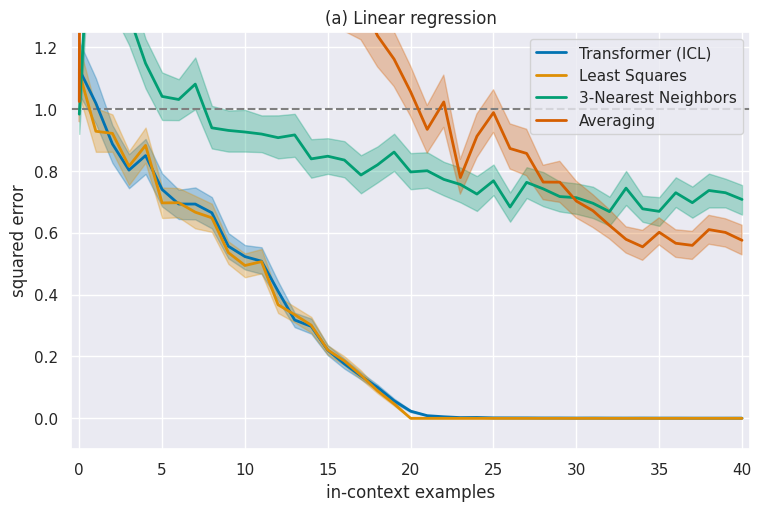

({'Transformer (ICL)': {'mean': [1.1277876853942872,
    1.0188979148864745,
    0.8869474411010743,
    0.8023898124694824,
    0.8492985725402832,
    0.7398039817810058,
    0.6927412986755371,
    0.6927013397216797,
    0.6645105838775635,
    0.5562163352966308,
    0.5228234767913819,
    0.5079295635223389,
    0.41086702346801757,
    0.31777851581573485,
    0.29726176261901854,
    0.22001516819000244,
    0.17620025873184203,
    0.13683584928512574,
    0.10015568733215333,
    0.05679428577423096,
    0.023152723908424377,
    0.008554156124591827,
    0.005008963495492935,
    0.002370491810142994,
    0.002804948017001152,
    0.0014797111973166466,
    0.0013758860528469085,
    0.001301159430295229,
    0.0010360392741858959,
    0.001019198913127184,
    0.0008173413574695587,
    0.0009277385659515857,
    0.0007544224616140127,
    0.0007083014585077763,
    0.0007841165177524089,
    0.0006739211268723011,
    0.0006966588087379932,
    0.0005738818552345037,
    

In [11]:
LINEAR_BASELINES = [
    LeastSquaresModel(),
    NNModel(n_neighbors=3),
    AveragingModel(),
]

LINEAR_MODEL_ORDER = [
    "Transformer (ICL)",
    "Least Squares",
    "3-Nearest Neighbors",
    "Averaging",
]

compute_and_plot_icl_task(
    "linear_regression",
    baselines_to_compute=LINEAR_BASELINES,
    model_order=LINEAR_MODEL_ORDER,
)


### Sparse Linear Regression



Task: (b) Sparse linear functions [sparse_linear_regression]
Computing ICL curves only: Transformer (ICL) plus the baselines listed in this cell
  eval: standard
  run:  /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/sparse_linear_regression/1bbcaa69-fe39-4335-abb2-28172861bf5a
  baselines: ['OLS_driver=None', 'averaging', 'lasso_alpha=0.01_max_iter=100000']
  y-axis: normalized squared error; x-axis: prompt length


1bbcaa69-fe39-4335-abb2-28172861bf5a:   0%|          | 0/1 [00:00<?, ?it/s]

    computing standard for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


    computing standard for OLS_driver=None


    computing standard for averaging


    computing standard for lasso_alpha=0.01_max_iter=100000


1bbcaa69-fe39-4335-abb2-28172861bf5a: 100%|██████████| 1/1 [00:29<00:00, 29.99s/it]

  done; curves available: ['Averaging', 'Lasso (alpha=0.01)', 'Least Squares', 'Transformer (ICL)']


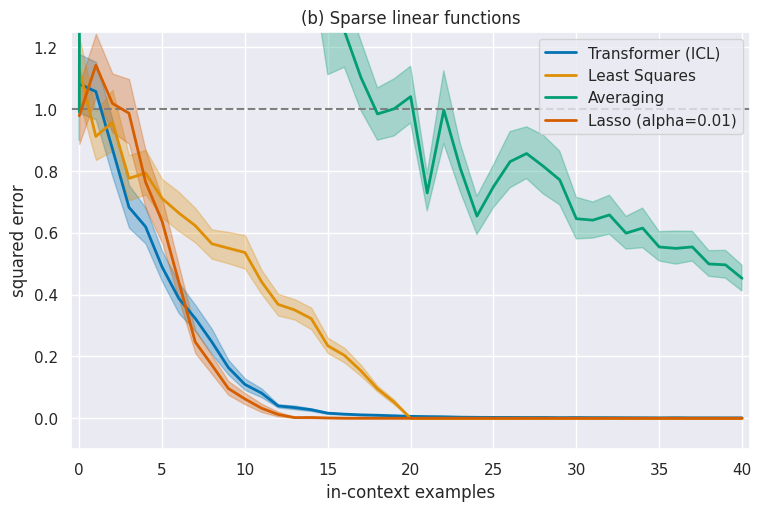

({'Transformer (ICL)': {'mean': [1.0810167789459229,
    1.0563581784566243,
    0.8712450663248698,
    0.6823236147562662,
    0.6195284525553385,
    0.4891830285390218,
    0.388275146484375,
    0.32296637694040936,
    0.24703594048817953,
    0.16394048929214478,
    0.10943352182706197,
    0.08166931569576263,
    0.04015350341796875,
    0.034637207786242165,
    0.027725890278816223,
    0.01661540816227595,
    0.013465413202842077,
    0.011168918261925379,
    0.00987700621287028,
    0.008187451089421907,
    0.006353943298260371,
    0.005572019765774409,
    0.004953154983619849,
    0.003673508142431577,
    0.0031819303209582963,
    0.0029464345425367355,
    0.0029306700453162193,
    0.0025929411252339682,
    0.002699469216167927,
    0.0022245673462748528,
    0.002561932119230429,
    0.0022323851784070334,
    0.002169202081859112,
    0.0019302771737178166,
    0.0017742076888680458,
    0.001472200732678175,
    0.001932099461555481,
    0.001508439425379037

In [12]:
SPARSE_BASELINES = [
    LeastSquaresModel(),
    AveragingModel(),
    LassoModel(alpha=0.01),
]

SPARSE_MODEL_ORDER = [
    "Transformer (ICL)",
    "Least Squares",
    "Averaging",
    "Lasso (alpha=0.01)",
]

compute_and_plot_icl_task(
    "sparse_linear_regression",
    baselines_to_compute=SPARSE_BASELINES,
    model_order=SPARSE_MODEL_ORDER,
)


### Decision Trees



Task: (c) Decision trees [decision_tree]
Computing ICL curves only: Transformer (ICL) plus the baselines listed in this cell
  eval: standard
  run:  /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/decision_tree/3cf4987d-48cd-407f-b874-a882c49e9331
  baselines: ['NN_n=3_uniform', 'decision_tree_max_depth=4', 'xgboost', 'decision_tree_max_depth=4_preprocess=sign', 'xgboost_preprocess=sign']
  eval overrides: {'parallel_batches': 10, 'parallel_seed': 12345}
  y-axis: normalized squared error; x-axis: prompt length


3cf4987d-48cd-407f-b874-a882c49e9331:   0%|          | 0/1 [00:00<?, ?it/s]

    computing standard for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


    computing standard for NN_n=3_uniform


    computing standard for decision_tree_max_depth=4


...

100%|██████████| 101/101 [02:25<00:00,  1.44s/it]


    computing standard for decision_tree_max_depth=4_preprocess=sign


    computing standard for xgboost_preprocess=sign


100%|██████████| 101/101 [01:09<00:00,  1.46it/s]

3cf4987d-48cd-407f-b874-a882c49e9331: 100%|██████████| 1/1 [08:29<00:00, 509.85s/it]

  done; curves available: ['3-Nearest Neighbors', 'Greedy Tree Learning', 'Greedy Tree Learning\n(w/ sign preproc.)', 'Transformer (ICL)', 'XGBoost', 'XGBoost\n(w/ sign preproc.)']


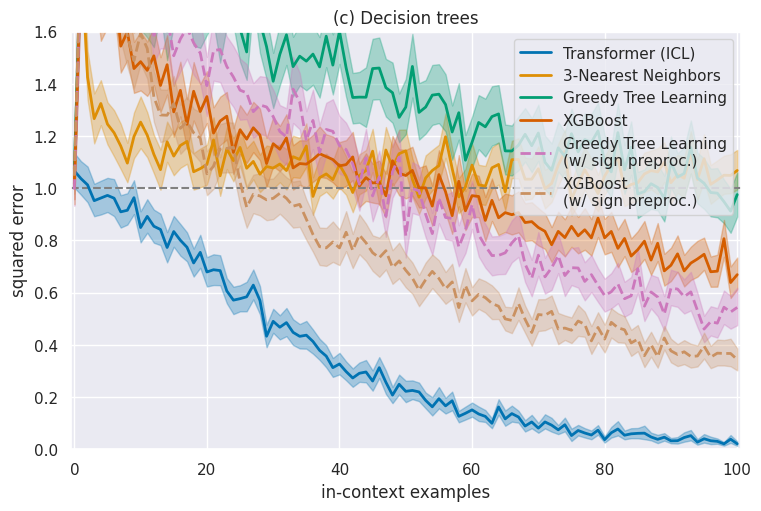

({'Transformer (ICL)': {'mean': [1.0667065382003784,
    1.037143349647522,
    1.0129938125610352,
    0.9524595141410828,
    0.9625266194343567,
    0.9726676940917969,
    0.9619248509407043,
    0.9096425771713257,
    0.9157028198242188,
    0.9640282392501831,
    0.849420428276062,
    0.8922370076179504,
    0.8544646501541138,
    0.8420241475105286,
    0.7730278968811035,
    0.8341466784477234,
    0.8007850646972656,
    0.7739654779434204,
    0.7137798070907593,
    0.754429280757904,
    0.6792235970497131,
    0.6877985000610352,
    0.684515655040741,
    0.6067046523094177,
    0.571330726146698,
    0.5769299268722534,
    0.5841747522354126,
    0.6288793683052063,
    0.5703425407409668,
    0.4330829977989197,
    0.4901501536369324,
    0.46754875779151917,
    0.4852294921875,
    0.4479209780693054,
    0.4326489567756653,
    0.43706703186035156,
    0.41303882002830505,
    0.3788558840751648,
    0.356977641582489,
    0.3126828074455261,
    0.32676017284

In [20]:
DECISION_TREE_BASELINES = [
    NNModel(n_neighbors=3),
    DecisionTreeModel(max_depth=4),
    XGBoostModel(n_jobs=1),
    DecisionTreeModel(max_depth=4, preprocess="sign"),
    XGBoostModel(n_jobs=1, preprocess="sign"),
]

DECISION_TREE_MODEL_ORDER = [
    "Transformer (ICL)",
    "3-Nearest Neighbors",
    "Greedy Tree Learning",
    "XGBoost",
    "Greedy Tree Learning\n(w/ sign preproc.)",
    "XGBoost\n(w/ sign preproc.)",
]

DECISION_TREE_EVAL_KWARGS = {
    "parallel_batches": 10,
    "parallel_seed": 12345,
}

compute_and_plot_icl_task(
    "decision_tree",
    baselines_to_compute=DECISION_TREE_BASELINES,
    model_order=DECISION_TREE_MODEL_ORDER,
    eval_kwargs_overrides=DECISION_TREE_EVAL_KWARGS,
)


### ReLU 2-Layer Neural Networks



Task: (d) 2-layer NN [relu_2nn_regression]
Computing ICL curves only: Transformer (ICL) plus the baselines listed in this cell
  eval: standard
  run:  /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/relu_2nn_regression/9f5157b6-5ca2-420d-a9fe-4dd30d619dda
  baselines: ['OLS_driver=None', 'NN_n=3_uniform', "gd_model_class=<class 'base_models.TwoLayerNeuralNetwork'>_model_class_args={'in_size': 20, 'hidden_size': 100, 'out_size': 1}_opt_alg=adam_lr=0.005_batch_size=100_num_steps=100_loss_name=squared_vectorized"]
  eval overrides: {'parallel_batches': 1}
  y-axis: normalized squared error; x-axis: prompt length


/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/src/eval.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(state_path)
9f5157b6-5ca2-420d-a9fe-4dd30d6

    computing standard for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


    computing standard for OLS_driver=None


    computing standard for NN_n=3_uniform


    computing standard for gd_model_class=<class 'base_models.TwoLayerNeuralNetwork'>_model_class_args={'in_size': 20, 'hidden_size': 100, 'out_size': 1}_opt_alg=adam_lr=0.005_batch_size=100_num_steps=100_loss_name=squared_vectorized

































































































100%|██████████| 101/101 [00:10<00:00,  9.32it/s]
































































































100%|██████████| 101/101 [00:10<00:00,  9.32it/s]































































































100%|██████████| 101/101 [00:10<00:00,  9.49it/s]
































































































100%|██████████| 101/101 [00:10<00:00,  9.45it/s]































































































100%|██████████| 101/101 [00:10<00:00,  9.50it/s]

































































































100%|██████████| 101/101 [00:10<00:00,  9.33it/s]
































































































100%|██████████| 101/101 [00:1

  done; curves available: ['2-layer NN, GD', '3-Nearest Neighbors', 'Least Squares', 'Transformer (ICL)']


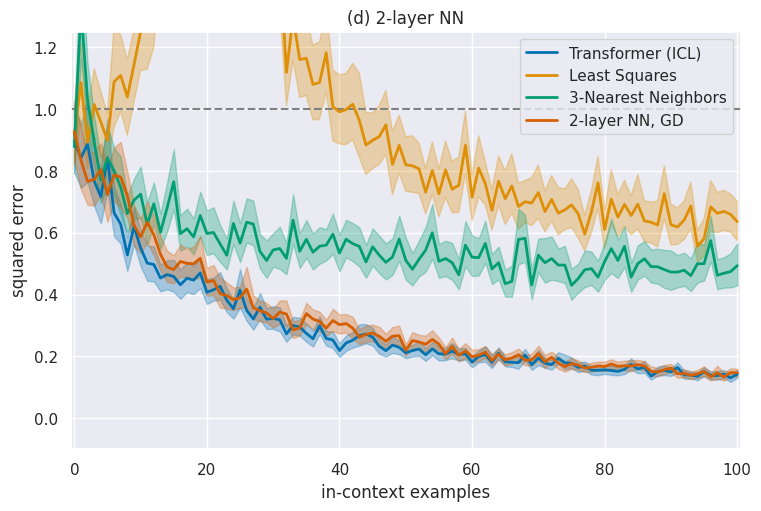

({'Transformer (ICL)': {'mean': [0.8966058492660522,
    0.84162437915802,
    0.8869578242301941,
    0.7667743563652039,
    0.7169955968856812,
    0.8419607281684875,
    0.6641734838485718,
    0.6276411414146423,
    0.5280616879463196,
    0.6199390292167664,
    0.5512340068817139,
    0.5017001032829285,
    0.4972318112850189,
    0.453554630279541,
    0.46475401520729065,
    0.4582664966583252,
    0.4318265914916992,
    0.4529988169670105,
    0.4466700553894043,
    0.4700540602207184,
    0.4073714315891266,
    0.41580185294151306,
    0.42661064863204956,
    0.38175636529922485,
    0.3544485569000244,
    0.4148429036140442,
    0.34870195388793945,
    0.3211982250213623,
    0.35933995246887207,
    0.32049307227134705,
    0.32308393716812134,
    0.31844982504844666,
    0.2728862464427948,
    0.29995059967041016,
    0.29537612199783325,
    0.2745199203491211,
    0.25738850235939026,
    0.29906171560287476,
    0.25831764936447144,
    0.25324732065200806,

In [15]:
# USE_CACHE = False

RELU_GD_BASELINE = GDModel(
    model_class=TwoLayerNeuralNetwork,
    model_class_args={"in_size": 20, "hidden_size": 100, "out_size": 1},
    opt_alg="adam",
    batch_size=100,
    lr=5e-3,
    num_steps=100,
)
RELU_GD_BASELINE.name = f"{RELU_GD_BASELINE.name}_vectorized"

RELU_BASELINES = [
    LeastSquaresModel(),
    NNModel(n_neighbors=3),
    RELU_GD_BASELINE,
]

RELU_MODEL_ORDER = [
    "Transformer (ICL)",
    "Least Squares",
    "3-Nearest Neighbors",
    "2-layer NN, GD",
]

RELU_EVAL_KWARGS = {"parallel_batches": 1}

compute_and_plot_icl_task(
    "relu_2nn_regression",
    baselines_to_compute=RELU_BASELINES,
    model_order=RELU_MODEL_ORDER,
    eval_kwargs_overrides=RELU_EVAL_KWARGS,
)


## Save Outputs


In [ ]:
output_dir = REPO_ROOT / "plots"
output_dir.mkdir(parents=True, exist_ok=True)

for task_name, fig in figures.items():
    png_path = output_dir / f"{task_name}_icl-{ICL_EVAL_NAME}.png"
    pdf_path = output_dir / f"{task_name}_icl-{ICL_EVAL_NAME}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", pdf_path)
